In [50]:
# Menghapus Transaction ID dari kolom yang akan di-encoding
categorical_columns = categorical_columns.drop('Transaction ID')

categorical_columns

Index(['Item', 'Payment Method', 'Location', 'Date Status', 'Month Name',
       'Day Name', 'Item Category', 'Spending Category'],
      dtype='object')

#### Membuat Ordinal encoding untuk Spending Category

In [51]:
# Membuat salinan data untuk proses encoding
df_encoding = df_scaled.copy()

# Mapping ordinal untuk Spending Category
spending_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4
}

# Membuat kolom baru hasil ordinal encoding
df_encoding['Spending Category Encoded'] = (
    df_encoding['Spending Category']
    .map(spending_mapping)
    .astype(int)
)

df_encoding[['Spending Category', 'Spending Category Encoded']].head()

,Spending Category,Spending Category Encoded
0,Low,1
1,High,3
2,Low,1
3,Medium,2
4,Low,1


#### One-hot Encoding

Encoding ini akan digunakan untuk kategori lainnya

In [52]:
# Menentukan kolom yang akan dilakukan one-hot encoding
columns_to_encode = [
    'Item',
    'Item Category',
    'Payment Method',
    'Location',
    'Month Name',
    'Day Name',
    'Date Status'
]

# Melakukan one-hot encoding
df_encoded = pd.get_dummies(
    df_encoding,
    columns=columns_to_encode,
    drop_first=False
)

df_encoded.head()

,Transaction ID,Quantity,Price Per Unit,Total Spent,Transaction Date,Year,Month,Spending Category,Quantity Scaled,Price Per Unit Scaled,...,Day Name_Friday,Day Name_Monday,Day Name_Saturday,Day Name_Sunday,Day Name_Thursday,Day Name_Tuesday,Day Name_Unknown,Day Name_Wednesday,Date Status_Date Available,Date Status_Date Missing
0,TXN_1961373,2,2.0,4.0,2023-09-08,2023,9,Low,0.25,0.25,...,True,False,False,False,False,False,False,False,True,False
1,TXN_4977031,4,3.0,12.0,2023-05-16,2023,5,High,0.75,0.50,...,False,False,False,False,False,True,False,False,True,False
2,TXN_4271903,4,1.0,4.0,2023-07-19,2023,7,Low,0.75,0.00,...,False,False,False,False,False,False,False,True,True,False
3,TXN_7034554,2,5.0,10.0,2023-04-27,2023,4,Medium,0.25,1.00,...,False,False,False,False,True,False,False,False,True,False
4,TXN_3160411,2,2.0,4.0,2023-06-11,2023,6,Low,0.25,0.25,...,False,False,False,True,False,False,False,False,True,False


Mengubah hasil encoding menjadi 0/1 dari True/false

In [53]:
# Mengubah kolom boolean hasil encoding menjadi integer 0 dan 1

bool_columns = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

df_encoded.head()

,Transaction ID,Quantity,Price Per Unit,Total Spent,Transaction Date,Year,Month,Spending Category,Quantity Scaled,Price Per Unit Scaled,...,Day Name_Friday,Day Name_Monday,Day Name_Saturday,Day Name_Sunday,Day Name_Thursday,Day Name_Tuesday,Day Name_Unknown,Day Name_Wednesday,Date Status_Date Available,Date Status_Date Missing
0,TXN_1961373,2,2.0,4.0,2023-09-08,2023,9,Low,0.25,0.25,...,1,0,0,0,0,0,0,0,1,0
1,TXN_4977031,4,3.0,12.0,2023-05-16,2023,5,High,0.75,0.50,...,0,0,0,0,0,1,0,0,1,0
2,TXN_4271903,4,1.0,4.0,2023-07-19,2023,7,Low,0.75,0.00,...,0,0,0,0,0,0,0,1,1,0
3,TXN_7034554,2,5.0,10.0,2023-04-27,2023,4,Medium,0.25,1.00,...,0,0,0,0,1,0,0,0,1,0
4,TXN_3160411,2,2.0,4.0,2023-06-11,2023,6,Low,0.25,0.25,...,0,0,0,1,0,0,0,0,1,0


In [54]:
# Mengecek hasil encoding

print("Jumlah kolom sebelum encoding:", df_scaled.shape[1])
print("Jumlah kolom setelah encoding:", df_encoded.shape[1])

print("\nKolom hasil encoding:")
print(df_encoded.columns)

Jumlah kolom sebelum encoding: 18
Jumlah kolom setelah encoding: 50

Kolom hasil encoding:
Index(['Transaction ID', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Transaction Date', 'Year', 'Month', 'Spending Category',
       'Quantity Scaled', 'Price Per Unit Scaled', 'Total Spent Scaled',
       'Spending Category Encoded', 'Item_Cake', 'Item_Coffee', 'Item_Cookie',
       'Item_Juice', 'Item_Salad', 'Item_Sandwich', 'Item_Smoothie',
       'Item_Tea', 'Item Category_Drinks', 'Item Category_Foods',
       'Payment Method_Cash', 'Payment Method_Credit Card',
       'Payment Method_Digital Wallet', 'Location_In-store',
       'Location_Takeaway', 'Month Name_April', 'Month Name_August',
       'Month Name_December', 'Month Name_February', 'Month Name_January',
       'Month Name_July', 'Month Name_June', 'Month Name_March',
       'Month Name_May', 'Month Name_November', 'Month Name_October',
       'Month Name_September', 'Month Name_Unknown', 'Day Name_Friday',
       'Day Nam

In [55]:
# Pengecekan missing value setelah encoding

df_encoded.isnull().sum()

Transaction ID                     0
Quantity                           0
Price Per Unit                     0
Total Spent                        0
Transaction Date                 460
Year                             460
Month                            460
Spending Category                  0
Quantity Scaled                    0
Price Per Unit Scaled              0
Total Spent Scaled                 0
Spending Category Encoded          0
Item_Cake                          0
Item_Coffee                        0
Item_Cookie                        0
Item_Juice                         0
Item_Salad                         0
Item_Sandwich                      0
Item_Smoothie                      0
Item_Tea                           0
Item Category_Drinks               0
Item Category_Foods                0
Payment Method_Cash                0
Payment Method_Credit Card         0
Payment Method_Digital Wallet      0
Location_In-store                  0
Location_Takeaway                  0
M

In [56]:
# Tampilan data awal hasil encoding

df_encoded.head()

,Transaction ID,Quantity,Price Per Unit,Total Spent,Transaction Date,Year,Month,Spending Category,Quantity Scaled,Price Per Unit Scaled,...,Day Name_Friday,Day Name_Monday,Day Name_Saturday,Day Name_Sunday,Day Name_Thursday,Day Name_Tuesday,Day Name_Unknown,Day Name_Wednesday,Date Status_Date Available,Date Status_Date Missing
0,TXN_1961373,2,2.0,4.0,2023-09-08,2023,9,Low,0.25,0.25,...,1,0,0,0,0,0,0,0,1,0
1,TXN_4977031,4,3.0,12.0,2023-05-16,2023,5,High,0.75,0.50,...,0,0,0,0,0,1,0,0,1,0
2,TXN_4271903,4,1.0,4.0,2023-07-19,2023,7,Low,0.75,0.00,...,0,0,0,0,0,0,0,1,1,0
3,TXN_7034554,2,5.0,10.0,2023-04-27,2023,4,Medium,0.25,1.00,...,0,0,0,0,1,0,0,0,1,0
4,TXN_3160411,2,2.0,4.0,2023-06-11,2023,6,Low,0.25,0.25,...,0,0,0,1,0,0,0,0,1,0


In [57]:
# Membuat dataset final numerik setelah encoding
df_model = df_encoded.drop(
    columns=[
        'Transaction ID',
        'Transaction Date',
        'Spending Category',
        'Year',
        'Month'
    ]
)

df_model.head()

,Quantity,Price Per Unit,Total Spent,Quantity Scaled,Price Per Unit Scaled,Total Spent Scaled,Spending Category Encoded,Item_Cake,Item_Coffee,Item_Cookie,...,Day Name_Friday,Day Name_Monday,Day Name_Saturday,Day Name_Sunday,Day Name_Thursday,Day Name_Tuesday,Day Name_Unknown,Day Name_Wednesday,Date Status_Date Available,Date Status_Date Missing
0,2,2.0,4.0,0.25,0.25,0.130435,1,0,1,0,...,1,0,0,0,0,0,0,0,1,0
1,4,3.0,12.0,0.75,0.50,0.478261,3,1,0,0,...,0,0,0,0,0,1,0,0,1,0
2,4,1.0,4.0,0.75,0.00,0.130435,1,0,0,1,...,0,0,0,0,0,0,0,1,1,0
3,2,5.0,10.0,0.25,1.00,0.391304,2,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,2,2.0,4.0,0.25,0.25,0.130435,1,0,1,0,...,0,0,0,1,0,0,0,0,1,0


In [58]:
# Mengecek missing value pada dataset final
df_model.isnull().sum()

Quantity                         0
Price Per Unit                   0
Total Spent                      0
Quantity Scaled                  0
Price Per Unit Scaled            0
Total Spent Scaled               0
Spending Category Encoded        0
Item_Cake                        0
Item_Coffee                      0
Item_Cookie                      0
Item_Juice                       0
Item_Salad                       0
Item_Sandwich                    0
Item_Smoothie                    0
Item_Tea                         0
Item Category_Drinks             0
Item Category_Foods              0
Payment Method_Cash              0
Payment Method_Credit Card       0
Payment Method_Digital Wallet    0
Location_In-store                0
Location_Takeaway                0
Month Name_April                 0
Month Name_August                0
Month Name_December              0
Month Name_February              0
Month Name_January               0
Month Name_July                  0
Month Name_June     

In [59]:
# Mengecek total missing value pada dataset final
print("Total missing value pada df_model:", df_model.isnull().sum().sum())

Total missing value pada df_model: 0


In [60]:
df_model.select_dtypes(include=['object', 'category', 'datetime']).columns

Index([], dtype='object')

In [61]:
# Mengecek tipe data pada dataset final
df_model.dtypes

Quantity                           int64
Price Per Unit                   float64
Total Spent                      float64
Quantity Scaled                  float64
Price Per Unit Scaled            float64
Total Spent Scaled               float64
Spending Category Encoded          int64
Item_Cake                          int64
Item_Coffee                        int64
Item_Cookie                        int64
Item_Juice                         int64
Item_Salad                         int64
Item_Sandwich                      int64
Item_Smoothie                      int64
Item_Tea                           int64
Item Category_Drinks               int64
Item Category_Foods                int64
Payment Method_Cash                int64
Payment Method_Credit Card         int64
Payment Method_Digital Wallet      int64
Location_In-store                  int64
Location_Takeaway                  int64
Month Name_April                   int64
Month Name_August                  int64
Month Name_Decem

In [62]:
# Mengecek apakah masih ada kolom object, category, atau datetime
df_model.select_dtypes(include=['object', 'category', 'datetime']).columns

Index([], dtype='object')

Setelah proses categorical data encoding, beberapa kolom kategorikal telah diubah menjadi bentuk numerik. Kolom Spending Category diubah menggunakan ordinal encoding karena memiliki tingkatan dari Low sampai Very High. Sementara itu, kolom Item, Item Category, Payment Method, Location, Month Name, Day Name, dan Date Status diubah menggunakan one-hot encoding karena tidak memiliki urutan tertentu.

Hasil encoding membuat dataset lebih siap digunakan untuk analisis lanjutan karena seluruh atribut kategorikal sudah direpresentasikan dalam bentuk numerik.

Berdasarkan tahap data manipulation, tema analisis difokuskan pada strategi peningkatan revenue cafe. Filtering digunakan untuk melihat transaksi bernilai tinggi dan produk dengan harga tinggi. Sorting digunakan untuk mengurutkan transaksi berdasarkan Total Spent terbesar. Groupby digunakan untuk mengetahui performa revenue berdasarkan item, metode pembayaran, dan lokasi transaksi. Feature engineering digunakan untuk menambahkan informasi waktu dan kategori spending. Scaling digunakan untuk menormalisasi data numerik agar siap digunakan pada analisis lanjutan. 

Dari hasil ini, pihak department dapat melihat produk mana yang paling berkontribusi terhadap revenue, bagaimana pola transaksi berdasarkan lokasi dan metode pembayaran, serta bagaimana tren penjualan berubah dari waktu ke waktu.

# DATA VISUALIZATION & EXPLORATORY DATA ANALYSIS

Pada tahap ini dataset hasil cleaning digunakan untuk membuat visualisasi dan analisis eksploratif. Selain kolom yang sudah ada, dibuat kategori baru bernama Item Category untuk mengelompokkan produk menjadi Foods dan Drinks.

In [63]:
# Setup visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style='whitegrid', palette='Set2')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

category_palette = {
    'Foods': '#FFB000',
    'Drinks': '#648FFF',
    'Unknown': '#999999'
}

payment_palette = {
    'Cash': '#99D98C',
    'Credit Card': '#76B7B2',
    'Digital Wallet': '#F4A261'
}

location_palette = {
    'In-store': '#FF9999',
    'Takeaway': '#66B3FF'
}

## 1. Reading & Extracting Data

Dataset yang digunakan adalah dataset hasil data cleaning dan data manipulation. Kolom **Item Category** dibuat untuk mempermudah analisis berdasarkan kelompok produk.

In [64]:
# Membuat dataset khusus untuk visualisasi dan EDA
df_viz = df_analysis.copy()

# Jika Item Category belum tersedia, buat ulang secara otomatis
food_items = ['Cake', 'Cookie', 'Salad', 'Sandwich']
drink_items = ['Coffee', 'Tea', 'Juice', 'Smoothie']

df_viz['Item Category'] = np.select(
    [
        df_viz['Item'].isin(food_items),
        df_viz['Item'].isin(drink_items)
    ],
    [
        'Foods',
        'Drinks'
    ],
    default='Unknown'
)

print("Ukuran dataset:", df_viz.shape)
print("\nDistribusi Item Category:")
print(df_viz['Item Category'].value_counts())

df_viz.head()

Ukuran dataset: (9976, 15)

Distribusi Item Category:
Item Category
Foods     4993
Drinks    4983
Name: count, dtype: int64


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Date Status,Year,Month,Month Name,Day Name,Item Category,Spending Category
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,Date Available,2023,9,September,Friday,Drinks,Low
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,Date Available,2023,5,May,Tuesday,Foods,High
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,Date Available,2023,7,July,Wednesday,Foods,Low
3,TXN_7034554,Salad,2,5.0,10.0,Credit Card,Takeaway,2023-04-27,Date Available,2023,4,April,Thursday,Foods,Medium
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,Date Available,2023,6,June,Sunday,Drinks,Low


In [65]:
# Mengecek informasi dasar dataset
df_viz.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9976 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Transaction ID     9976 non-null   object        
 1   Item               9976 non-null   object        
 2   Quantity           9976 non-null   int64         
 3   Price Per Unit     9976 non-null   float64       
 4   Total Spent        9976 non-null   float64       
 5   Payment Method     9976 non-null   object        
 6   Location           9976 non-null   object        
 7   Transaction Date   9516 non-null   datetime64[ns]
 8   Date Status        9976 non-null   object        
 9   Year               9516 non-null   Int64         
 10  Month              9516 non-null   Int64         
 11  Month Name         9976 non-null   object        
 12  Day Name           9976 non-null   object        
 13  Item Category      9976 non-null   object        
 14  Spending Cate

In [66]:
# Mengecek tipe data
df_viz.dtypes

Transaction ID               object
Item                         object
Quantity                      int64
Price Per Unit              float64
Total Spent                 float64
Payment Method               object
Location                     object
Transaction Date     datetime64[ns]
Date Status                  object
Year                          Int64
Month                         Int64
Month Name                   object
Day Name                     object
Item Category                object
Spending Category          category
dtype: object

In [67]:
# Mengecek missing value
df_viz.isnull().sum()

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method         0
Location               0
Transaction Date     460
Date Status            0
Year                 460
Month                460
Month Name             0
Day Name               0
Item Category          0
Spending Category      0
dtype: int64

In [68]:
# Mengecek duplicated data
print("Jumlah data duplikat:", df_viz.duplicated().sum())

Jumlah data duplikat: 0


In [69]:
# Statistik deskriptif kolom numerik
df_viz[['Quantity', 'Price Per Unit', 'Total Spent']].describe()

,Quantity,Price Per Unit,Total Spent
count,9976.000000,9976.000000,9976.000000
mean,3.025060,2.947173,8.929030
std,1.420499,1.280181,6.004199
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [70]:
# Deteksi outlier menggunakan metode IQR
numerical_columns = ['Quantity', 'Price Per Unit', 'Total Spent']

outlier_summary = []

for col in numerical_columns:
    Q1 = df_viz[col].quantile(0.25)
    Q3 = df_viz[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = df_viz[
        (df_viz[col] < lower_bound) | 
        (df_viz[col] > upper_bound)
    ].shape[0]

    outlier_summary.append({
        'Column': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,Column,Lower Bound,Upper Bound,Outlier Count
0,Quantity,-1.0,7.0,0
1,Price Per Unit,-1.0,7.0,0
2,Total Spent,-8.0,24.0,269


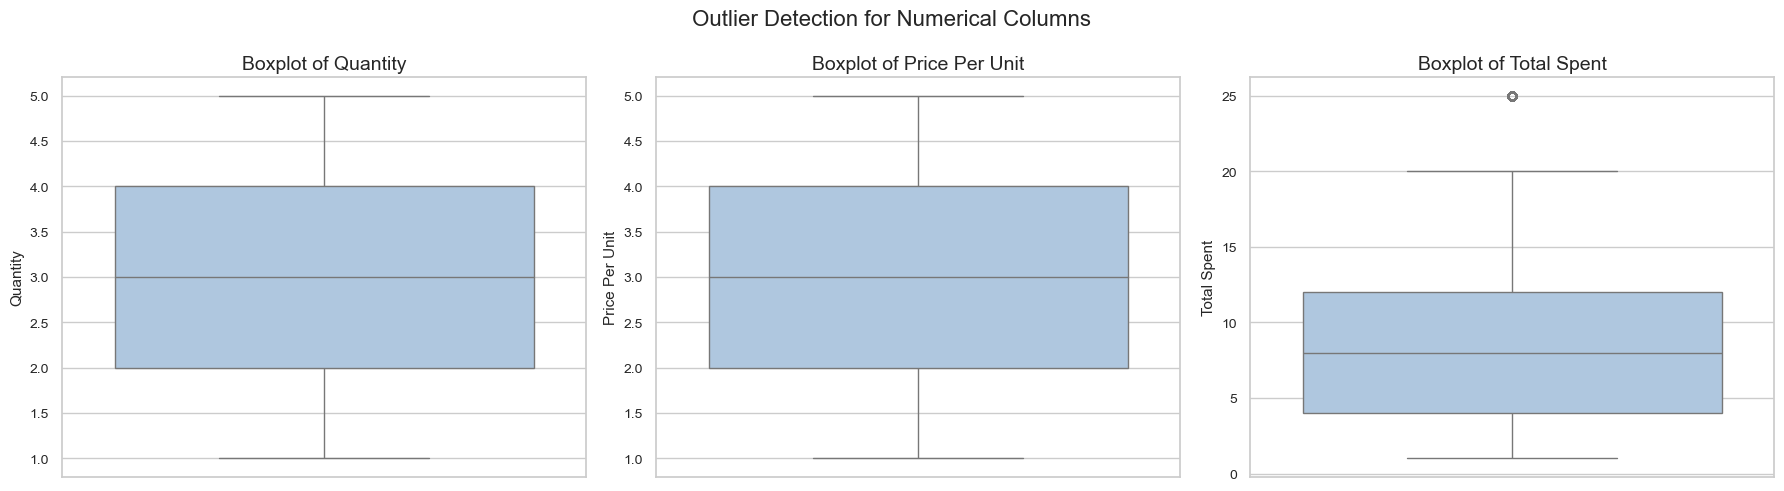

In [71]:
# Visualisasi outlier dengan boxplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numerical_columns):
    sns.boxplot(data=df_viz, y=col, ax=ax, color='#A7C7E7')
    ax.set_title(f'Boxplot of {col}')
    ax.set_ylabel(col)

plt.suptitle('Outlier Detection for Numerical Columns', fontsize=16)
plt.tight_layout()
plt.show()

Berdasarkan pengecekan awal, kolom utama transaksi sudah dapat digunakan untuk proses visualisasi dan EDA. Kolom **Transaction Date** tetap dibiarkan kosong pada beberapa baris, sehingga analisis berbasis waktu hanya menggunakan data yang memiliki tanggal transaksi.

## 1.1 Transaction Date Missingness Analysis

Pada bagian ini, nilai kosong pada kolom Transaction Date dianalisis lebih lanjut. Perlu diperhatikan bahwa bulan pasti dari data yang tanggalnya kosong tidak dapat diketahui secara langsung, karena informasi bulan berasal dari Transaction Date itu sendiri.

Namun, data kosong tersebut tetap bisa dianalisis melalui beberapa pendekatan:

1. Menghitung jumlah dan persentase data dengan tanggal kosong.
2. Melihat kelompok mana yang paling sering memiliki tanggal kosong, misalnya berdasarkan Item Category, Item, Payment Method, dan Location.
3. Membandingkan data dengan tanggal tersedia terhadap data dengan tanggal kosong.
4. Menggunakan kategori "Unknown" pada "Month Name" dan Day Name" sebagai penanda transaksi yang tidak memiliki tanggal valid.


In [72]:
# Ringkasan ketersediaan Transaction Date

date_status_summary = (
    df_viz['Date Status']
    .value_counts()
    .rename_axis('Date Status')
    .reset_index(name='Transaction Count')
)

date_status_summary['Percentage'] = (
    date_status_summary['Transaction Count'] / len(df_viz) * 100
).round(2)

date_status_summary

,Date Status,Transaction Count,Percentage
0,Date Available,9516,95.39
1,Date Missing,460,4.61


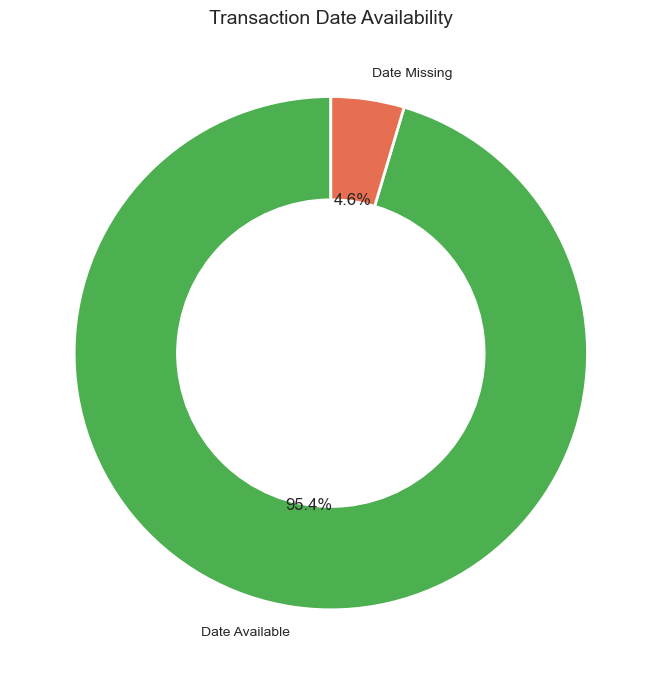

In [73]:
# Donut chart untuk melihat proporsi Transaction Date yang tersedia dan kosong

fig, ax = plt.subplots(figsize=(7, 7))

status_colors = {
    'Date Available': '#4CAF50',
    'Date Missing': '#E76F51'
}

colors = [status_colors.get(label, '#999999') for label in date_status_summary['Date Status']]

ax.pie(
    date_status_summary['Transaction Count'],
    labels=date_status_summary['Date Status'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

centre_circle = plt.Circle((0, 0), 0.60, fc='white')
ax.add_artist(centre_circle)

ax.set_title('Transaction Date Availability')
plt.tight_layout()
plt.show()

Grafik donut menunjukkan proporsi transaksi yang memiliki tanggal valid dan transaksi yang tidak memiliki tanggal valid. Bagian **Date Missing** tidak dibuang karena transaksi tersebut masih bisa digunakan untuk analisis non-waktu, seperti analisis produk, metode pembayaran, lokasi, dan nilai transaksi.

In [74]:
# Fungsi untuk menghitung missing rate Transaction Date berdasarkan kelompok tertentu

def missing_rate_by(group_col):
    summary = df_viz.groupby(group_col).agg(
        Total_Transactions=('Transaction ID', 'count'),
        Missing_Date=('Transaction Date', lambda x: x.isna().sum()),
        Total_Revenue=('Total Spent', 'sum'),
        Average_Spending=('Total Spent', 'mean')
    )

    summary['Missing_Date_Rate_%'] = (
        summary['Missing_Date'] / summary['Total_Transactions'] * 100
    ).round(2)

    return summary.sort_values(by='Missing_Date_Rate_%', ascending=False)

missing_by_category = missing_rate_by('Item Category')
missing_by_item = missing_rate_by('Item')
missing_by_payment = missing_rate_by('Payment Method')
missing_by_location = missing_rate_by('Location')

missing_by_category

,Total_Transactions,Missing_Date,Total_Revenue,Average_Spending,Missing_Date_Rate_%
Item Category,,,,,
Foods,4993,244,49537.0,9.921290,4.89
Drinks,4983,216,39539.0,7.934778,4.33


In [75]:
# Menampilkan missing rate berdasarkan Item, Payment Method, dan Location

print('Missing Date Rate by Item:')
display(missing_by_item)

print() 
print('Missing Date Rate by Payment Method:')
display(missing_by_payment)

print()
print('Missing Date Rate by Location:')
display(missing_by_location)

Missing Date Rate by Item:


,Total_Transactions,Missing_Date,Total_Revenue,Average_Spending,Missing_Date_Rate_%
Item,,,,,
Tea,1206,65,5475.0,4.539801,5.39
Cookie,1211,62,3598.0,2.971098,5.12
Sandwich,1248,63,15296.0,12.256410,5.05
Cake,1263,63,11523.0,9.123515,4.99
Salad,1271,56,19120.0,15.043273,4.41
Smoothie,1200,52,14580.0,12.150000,4.33
Juice,1291,54,11676.0,9.044152,4.18
Coffee,1286,45,7808.0,6.071540,3.50



Missing Date Rate by Payment Method:


,Total_Transactions,Missing_Date,Total_Revenue,Average_Spending,Missing_Date_Rate_%
Payment Method,,,,,
Credit Card,3323,174,29787.0,8.963888,5.24
Digital Wallet,3353,147,29590.5,8.825082,4.38
Cash,3300,139,29698.5,8.999545,4.21



Missing Date Rate by Location:


,Total_Transactions,Missing_Date,Total_Revenue,Average_Spending,Missing_Date_Rate_%
Location,,,,,
In-store,4990,230,44821.5,8.982265,4.61
Takeaway,4986,230,44254.5,8.875752,4.61


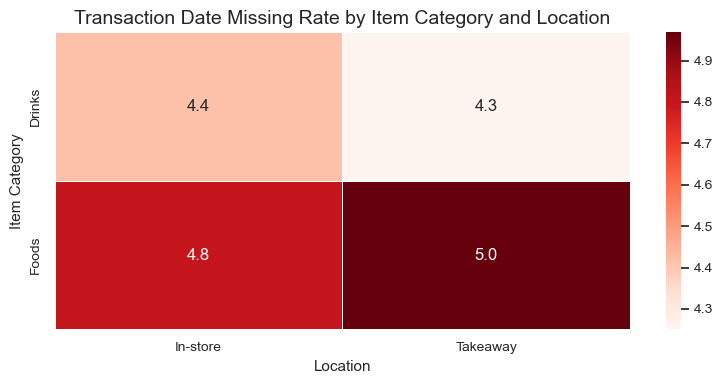

In [76]:
# Heatmap missing rate Transaction Date berdasarkan Item Category dan Location

missing_pivot = pd.crosstab(
    index=df_viz['Item Category'],
    columns=df_viz['Location'],
    values=df_viz['Transaction Date'].isna(),
    aggfunc='mean'
).fillna(0) * 100

plt.figure(figsize=(8, 4))
ax = sns.heatmap(
    missing_pivot,
    annot=True,
    fmt='.1f',
    cmap='Reds',
    linewidths=0.5
)

ax.set_title('Transaction Date Missing Rate by Item Category and Location')
ax.set_xlabel('Location')
ax.set_ylabel('Item Category')
plt.tight_layout()
plt.show()

Pada heatmap di atas, nilai yang ditampilkan adalah persentase missing Transaction Date. Warna merah yang lebih gelap menunjukkan missing rate yang lebih tinggi.

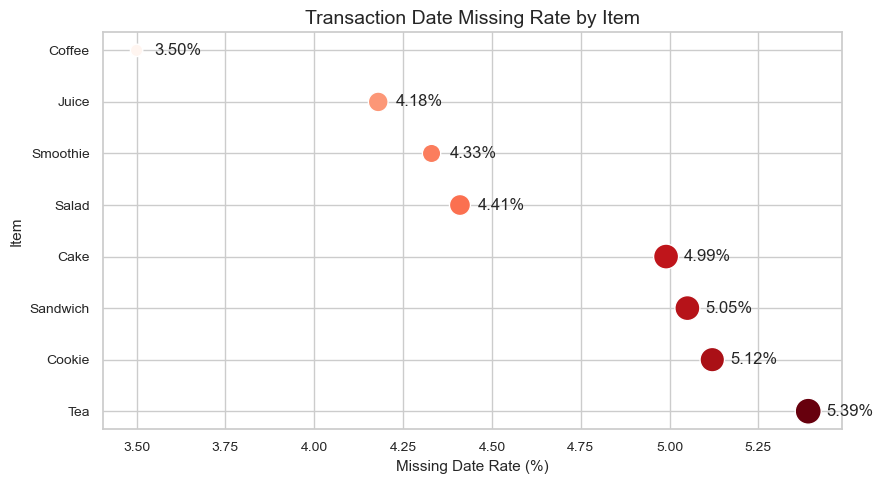

In [77]:
# Dot plot missing rate berdasarkan Item

missing_item_plot = missing_by_item.reset_index().sort_values('Missing_Date_Rate_%')

plt.figure(figsize=(9, 5))
ax = sns.scatterplot(
    data=missing_item_plot,
    x='Missing_Date_Rate_%',
    y='Item',
    size='Missing_Date',
    hue='Missing_Date_Rate_%',
    palette='Reds',
    sizes=(80, 350),
    legend=False
)

for _, row in missing_item_plot.iterrows():
    ax.text(
        row['Missing_Date_Rate_%'] + 0.05,
        row['Item'],
        f"{row['Missing_Date_Rate_%']:.2f}%",
        va='center'
    )

ax.set_title('Transaction Date Missing Rate by Item')
ax.set_xlabel('Missing Date Rate (%)')
ax.set_ylabel('Item')
plt.tight_layout()
plt.show()

Dot plot membantu melihat item mana yang memiliki persentase tanggal kosong paling tinggi. Ukuran titik menunjukkan jumlah data tanggal kosong, sedangkan posisi titik menunjukkan persentase missing date pada setiap item.

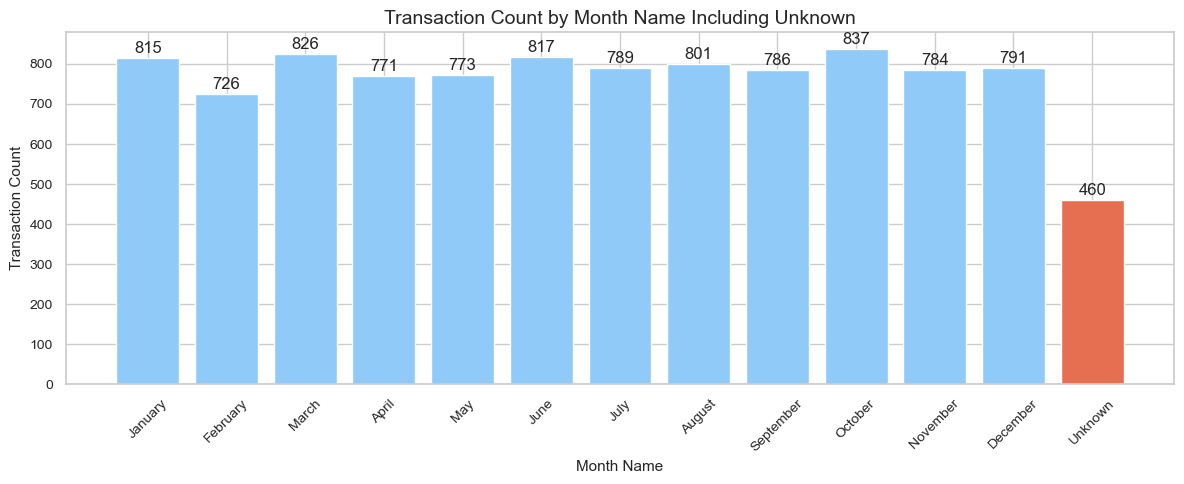

In [78]:
# Distribusi Month Name termasuk kategori Unknown
# Unknown merepresentasikan data yang Transaction Date-nya kosong atau tidak valid.

month_with_unknown_order = month_order + ['Unknown']

month_status_count = (
    df_viz['Month Name']
    .value_counts()
    .reindex(month_with_unknown_order)
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#90CAF9' if month != 'Unknown' else '#E76F51' for month in month_status_count.index]

ax.bar(
    month_status_count.index,
    month_status_count.values,
    color=colors,
    edgecolor='white'
)

ax.set_title('Transaction Count by Month Name Including Unknown')
ax.set_xlabel('Month Name')
ax.set_ylabel('Transaction Count')
ax.tick_params(axis='x', rotation=45)

for i, value in enumerate(month_status_count.values):
    ax.text(i, value + 5, value, ha='center', va='bottom')

plt.tight_layout()
plt.show()

Grafik ini tidak menunjukkan bulan asli dari data yang hilang, karena bulan tersebut memang tidak tersedia. Kategori **Unknown** digunakan sebagai penanda jumlah transaksi yang tidak memiliki tanggal valid. Dengan demikian, analisis waktu tetap dilakukan pada bulan Januari sampai Desember, sedangkan data tanggal kosong dianalisis sebagai kelompok data quality tersendiri.

## 2. Fundamentals Visualization

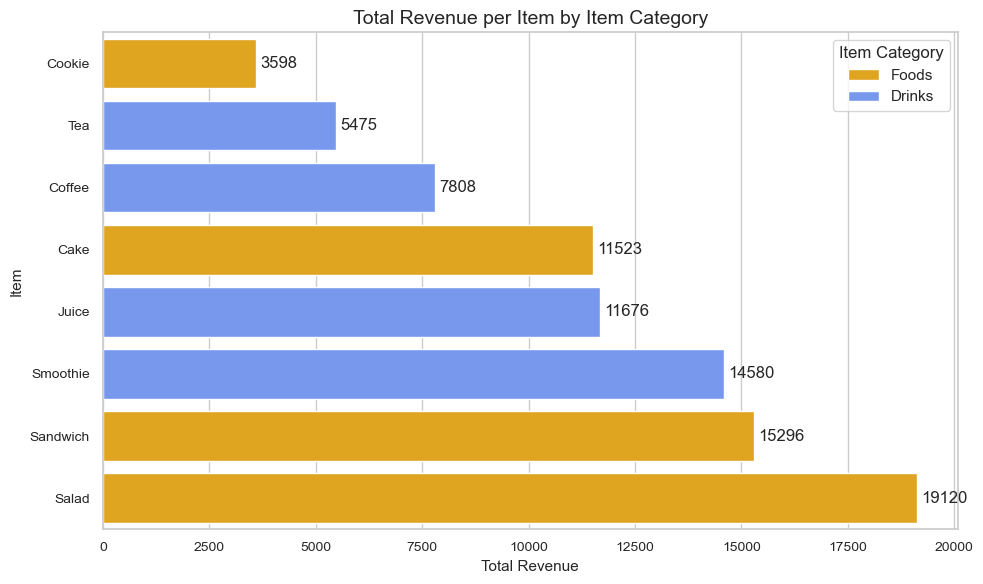

In [79]:
# Grafik 1: Total Revenue per Item dengan kategori Foods/Drinks

item_revenue = (
    df_viz.groupby(['Item Category', 'Item'])['Total Spent']
    .sum()
    .reset_index()
    .sort_values(by='Total Spent', ascending=True)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=item_revenue,
    x='Total Spent',
    y='Item',
    hue='Item Category',
    palette=category_palette
)

ax.set_title('Total Revenue per Item by Item Category')
ax.set_xlabel('Total Revenue')
ax.set_ylabel('Item')
ax.legend(title='Item Category')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

Grafik ini menunjukkan kontribusi revenue setiap item dengan pemisahan kategori **Foods** dan **Drinks**. Dengan kategori ini, produk makanan dan minuman dapat dibandingkan dengan lebih jelas berdasarkan pendapatan yang dihasilkan.

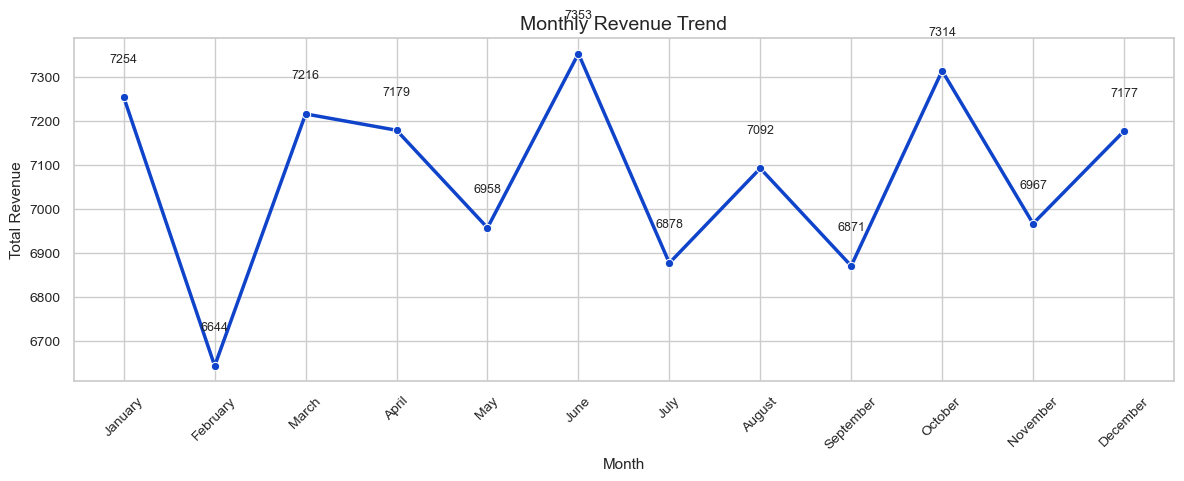

In [80]:
# Grafik 2: Monthly Revenue Trend
# Hanya menggunakan data yang memiliki Transaction Date

monthly_revenue = (
    df_time_analysis
    .groupby('Month Name')['Total Spent']
    .sum()
    .reindex(month_order)
)

plt.figure(figsize=(12, 5))
ax = sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    marker='o',
    linewidth=2.5,
    color="#0F44CA"
)

ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')
plt.xticks(rotation=45)

for x, y in zip(monthly_revenue.index, monthly_revenue.values):
    ax.text(x, y + 80, f'{y:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Line chart menunjukkan tren revenue bulanan. Karena tidak semua baris memiliki tanggal transaksi, grafik ini hanya menggunakan data yang lengkap pada kolom **Transaction Date**.

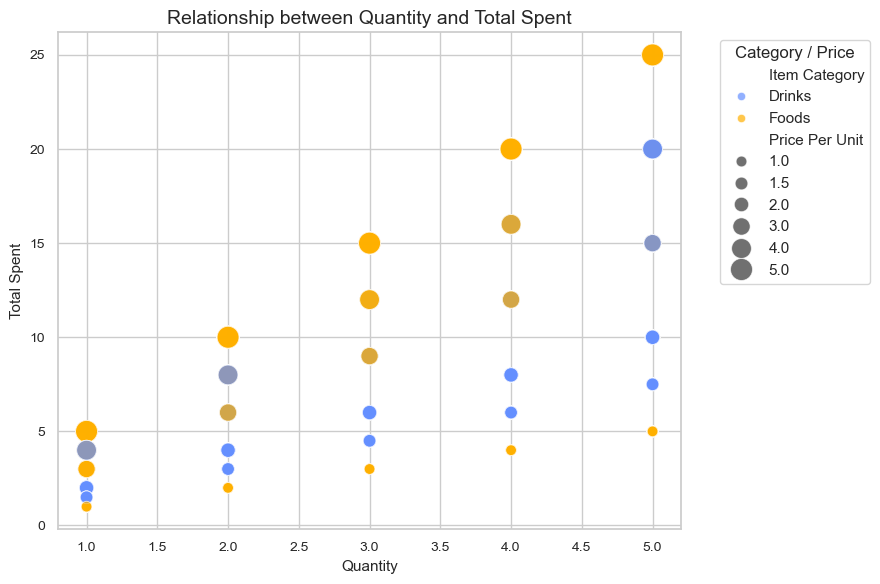

In [81]:
# Grafik 3: Scatter Plot Quantity vs Total Spent
# Warna menunjukkan Item Category dan ukuran titik menunjukkan Price Per Unit

plt.figure(figsize=(9, 6))
ax = sns.scatterplot(
    data=df_viz,
    x='Quantity',
    y='Total Spent',
    hue='Item Category',
    size='Price Per Unit',
    sizes=(60, 250),
    alpha=0.7,
    palette=category_palette
)

ax.set_title('Relationship between Quantity and Total Spent')
ax.set_xlabel('Quantity')
ax.set_ylabel('Total Spent')
ax.legend(title='Category / Price', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Scatter plot menunjukkan hubungan antara jumlah barang yang dibeli dan total transaksi. Warna kategori membantu melihat apakah pola transaksi makanan dan minuman memiliki perbedaan.

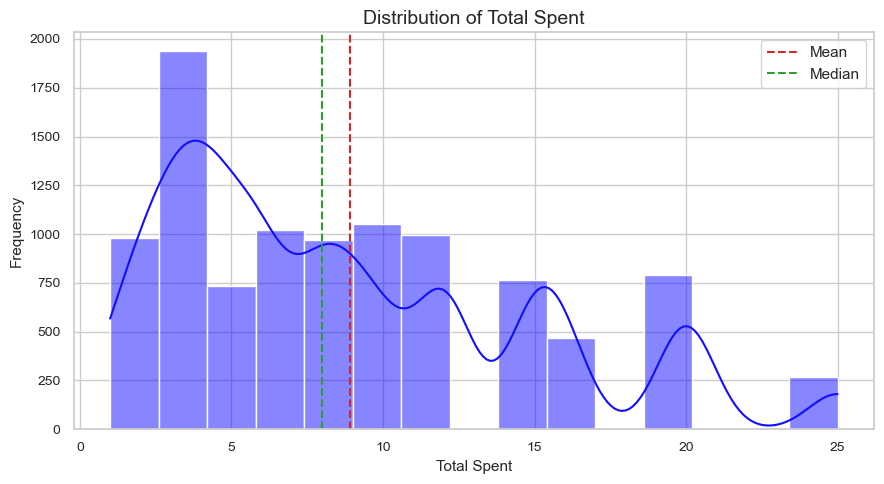

In [82]:
# Grafik 4: Distribution of Total Spent

plt.figure(figsize=(9, 5))
ax = sns.histplot(
    data=df_viz,
    x='Total Spent',
    bins=15,
    kde=True,
    color="#110DFF",
    edgecolor='white'
)

ax.axvline(df_viz['Total Spent'].mean(), color='#D62728', linestyle='--', label='Mean')
ax.axvline(df_viz['Total Spent'].median(), color='#2CA02C', linestyle='--', label='Median')

ax.set_title('Distribution of Total Spent')
ax.set_xlabel('Total Spent')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

Histogram menunjukkan sebaran nilai transaksi. Garis mean dan median digunakan untuk membantu melihat kecenderungan pusat data dan apakah distribusi transaksi cenderung miring.

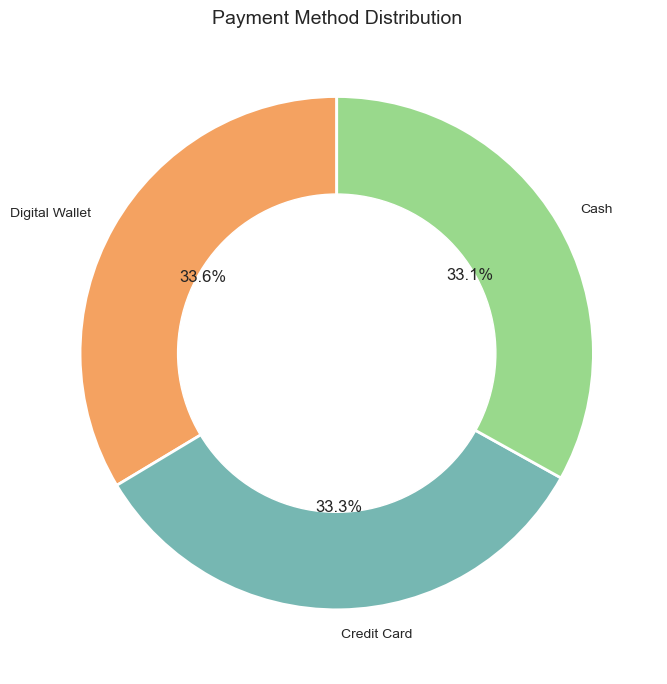

In [83]:
# Grafik 5: Donut Chart Payment Method Distribution

payment_counts = df_viz['Payment Method'].value_counts()
colors = [payment_palette.get(label, '#BBBBBB') for label in payment_counts.index]

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

centre_circle = plt.Circle((0, 0), 0.62, fc='white')
ax.add_artist(centre_circle)

ax.set_title('Payment Method Distribution')
plt.tight_layout()
plt.show()

Donut chart menunjukkan proporsi metode pembayaran yang digunakan pelanggan. Grafik ini membantu melihat metode pembayaran yang paling dominan dalam transaksi cafe.

C:\Users\MSI1\AppData\Local\Temp\ipykernel_12908\981853204.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


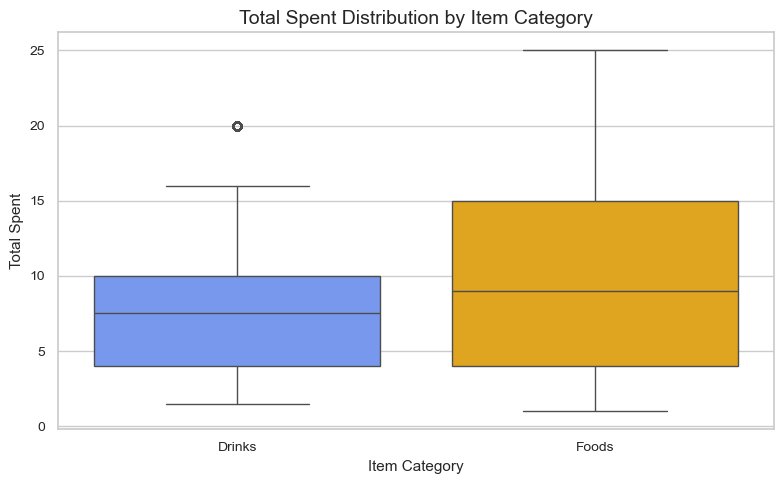

In [84]:
# Grafik 6: Boxplot Total Spent by Item Category

plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=df_viz,
    x='Item Category',
    y='Total Spent',
    palette=category_palette
)

ax.set_title('Total Spent Distribution by Item Category')
ax.set_xlabel('Item Category')
ax.set_ylabel('Total Spent')

plt.tight_layout()
plt.show()

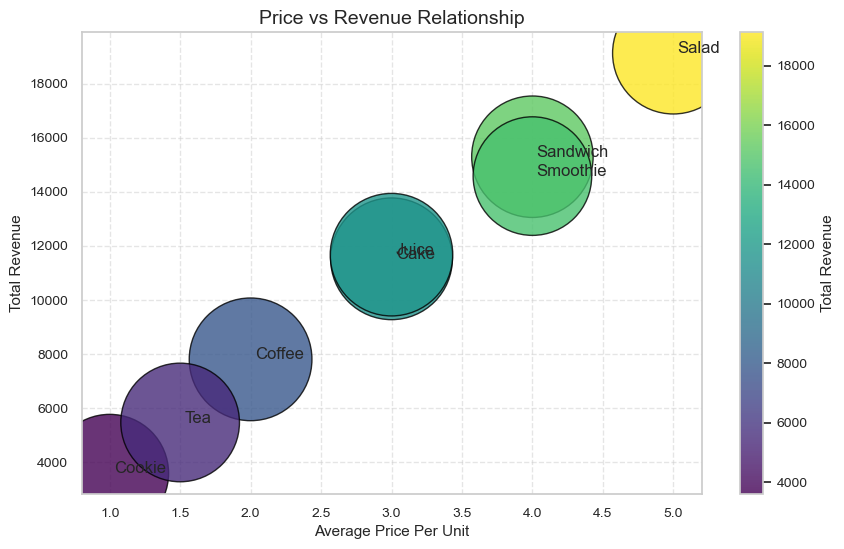

In [85]:
# Grafik 6: Price vs Revenue Relationship

item_analysis = df_viz.groupby('Item').agg({
    'Price Per Unit': 'mean',
    'Total Spent': 'sum',
    'Quantity': 'sum'
}).reset_index()

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    item_analysis['Price Per Unit'],
    item_analysis['Total Spent'],
    s=item_analysis['Quantity'] * 2,
    c=item_analysis['Total Spent'],
    cmap='viridis',
    alpha=0.8,
    edgecolor='black'
)

# Menambahkan label nama item
for i in range(len(item_analysis)):
    plt.text(
        item_analysis['Price Per Unit'][i] + 0.03,
        item_analysis['Total Spent'][i],
        item_analysis['Item'][i]
    )

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Total Revenue')

plt.title('Price vs Revenue Relationship')
plt.xlabel('Average Price Per Unit')
plt.ylabel('Total Revenue')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Boxplot membandingkan distribusi nilai transaksi antara kategori **Foods** dan **Drinks**. Grafik ini membantu melihat perbedaan median, rentang data, dan potensi outlier pada masing-masing kategori.

## 3. Advanced Visualization

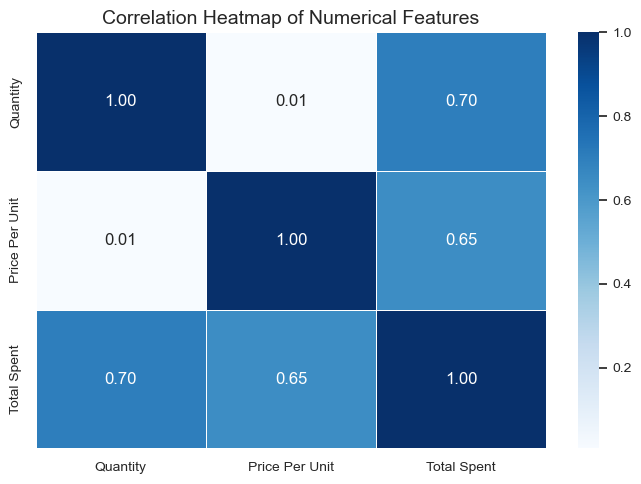

In [86]:
# Advanced Chart 1: Correlation Heatmap

numeric_corr = df_viz[['Quantity', 'Price Per Unit', 'Total Spent']].corr()

plt.figure(figsize=(7, 5))
ax = sns.heatmap(
    numeric_corr,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5
)

ax.set_title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

Heatmap menunjukkan hubungan antar variabel numerik. Total Spent berkaitan dengan Quantity dan Price Per Unit karena nilai transaksi terbentuk dari kombinasi kedua variabel tersebut.

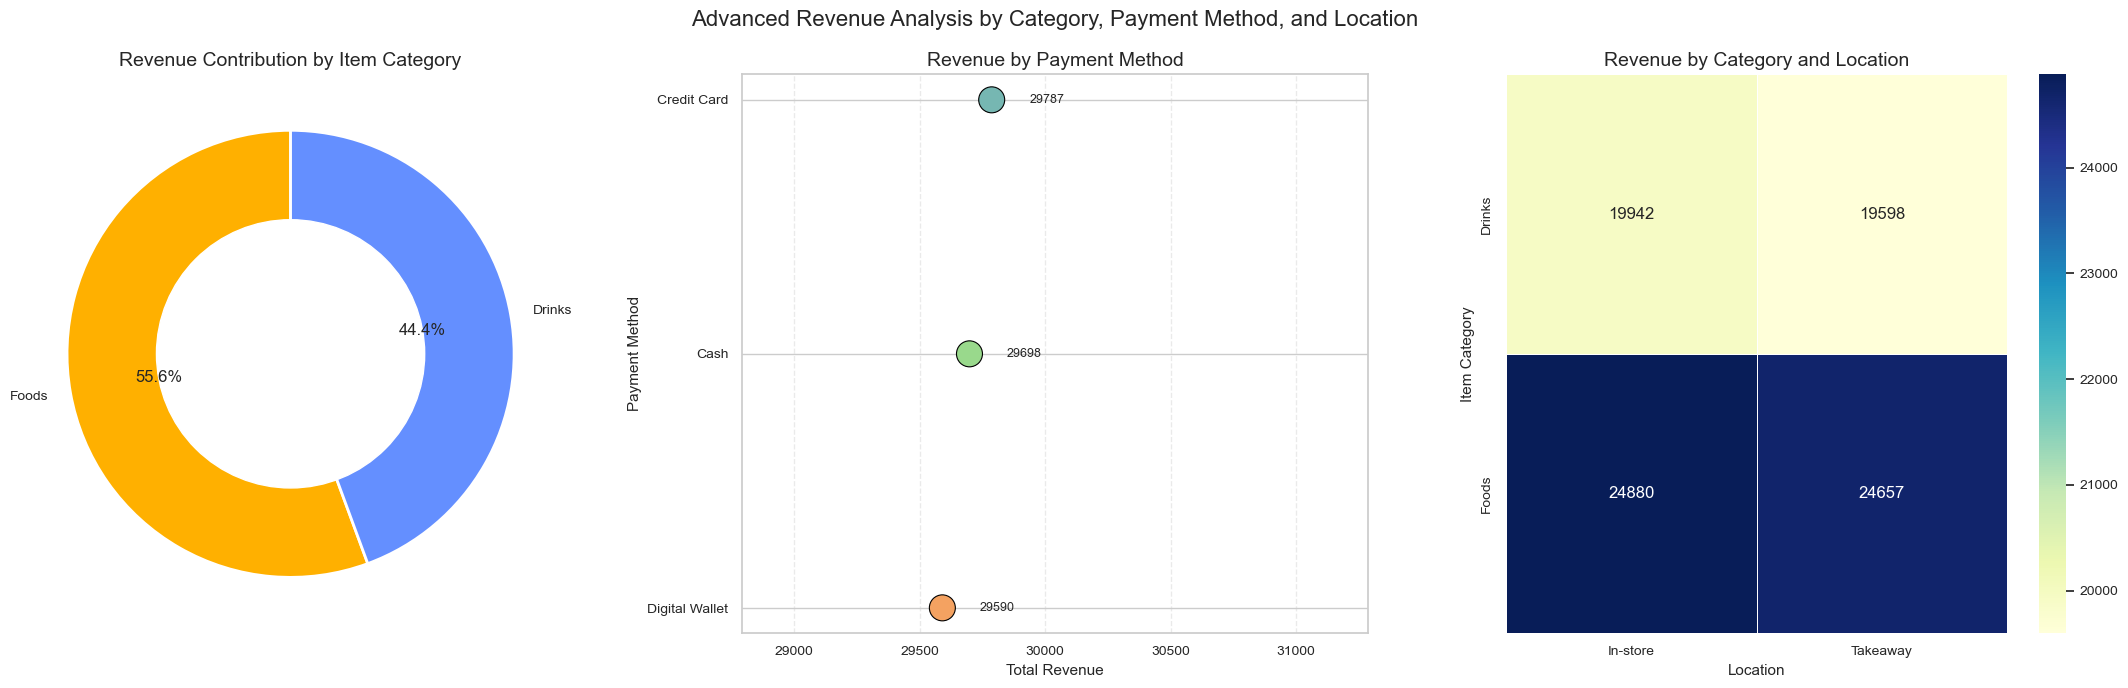

In [87]:
# Advanced Chart 2: Mixed Subplot Visualization
# Menggunakan visualisasi berbeda agar tidak terlalu banyak mengulang bar chart

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ======================================================
# Axis 1: Donut Chart - Revenue by Item Category
# ======================================================

category_revenue = (
    df_viz.groupby('Item Category')['Total Spent']
    .sum()
    .sort_values(ascending=False)
)

category_colors = [category_palette.get(label, '#BBBBBB') for label in category_revenue.index]

axes[0].pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=category_colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

centre_circle = plt.Circle((0, 0), 0.60, fc='white')
axes[0].add_artist(centre_circle)
axes[0].set_title('Revenue Contribution by Item Category')


# ======================================================
# Axis 2: Dot Plot - Revenue by Payment Method
# ======================================================

payment_revenue = (
    df_viz.groupby('Payment Method')['Total Spent']
    .sum()
    .sort_values(ascending=True)
)

payment_colors = [payment_palette.get(label, '#BBBBBB') for label in payment_revenue.index]

axes[1].scatter(
    payment_revenue.values,
    payment_revenue.index,
    s=350,
    color=payment_colors,
    edgecolor='black',
    linewidth=0.8
)

axes[1].set_title('Revenue by Payment Method')
axes[1].set_xlabel('Total Revenue')
axes[1].set_ylabel('Payment Method')
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

for value, label in zip(payment_revenue.values, payment_revenue.index):
    axes[1].text(
        value + 150,
        label,
        f'{value:.0f}',
        va='center',
        fontsize=9
    )

axes[1].set_xlim(payment_revenue.min() - 800, payment_revenue.max() + 1500)


# ======================================================
# Axis 3: Heatmap - Revenue by Item Category and Location
# ======================================================

category_location = df_viz.pivot_table(
    values='Total Spent',
    index='Item Category',
    columns='Location',
    aggfunc='sum'
)

sns.heatmap(
    category_location,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=axes[2]
)

axes[2].set_title('Revenue by Category and Location')
axes[2].set_xlabel('Location')
axes[2].set_ylabel('Item Category')

plt.suptitle('Advanced Revenue Analysis by Category, Payment Method, and Location', fontsize=16)
plt.tight_layout()
plt.show()

Visualisasi subplot ini menggabungkan tiga bentuk grafik berbeda. Donut chart digunakan untuk melihat komposisi revenue kategori produk, dot plot digunakan untuk membandingkan revenue antar metode pembayaran, dan heatmap digunakan untuk melihat kombinasi revenue antara kategori produk dan lokasi.

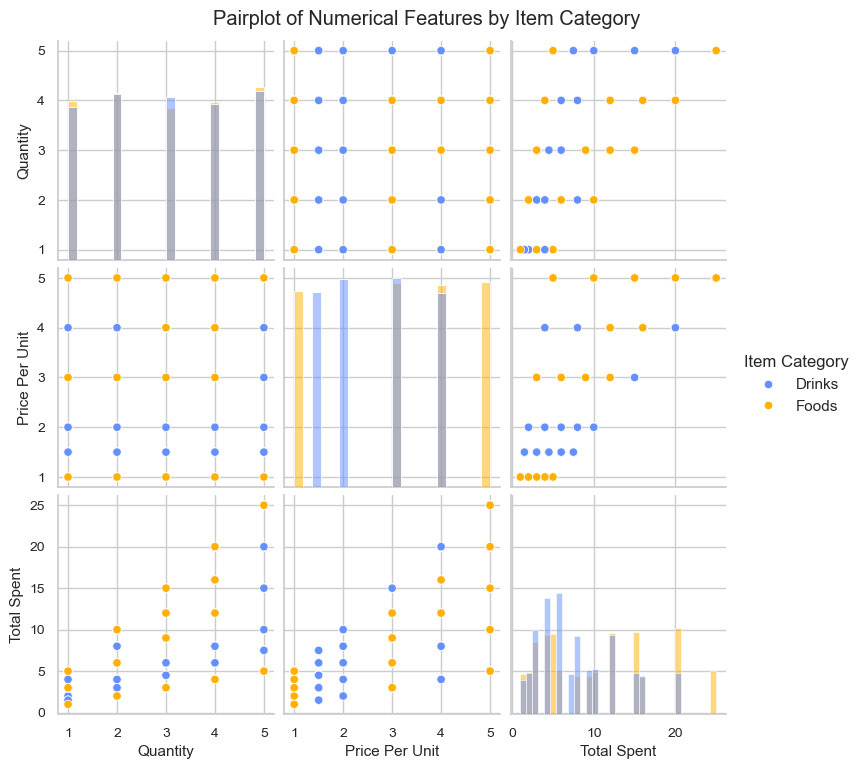

In [88]:
# Advanced Chart 3: Pairplot Numerical Features by Item Category

pairplot_data = df_viz[
    ['Quantity', 'Price Per Unit', 'Total Spent', 'Item Category']
].copy()

sns.pairplot(
    pairplot_data,
    hue='Item Category',
    diag_kind='hist',
    palette=category_palette,
    height=2.5
)

plt.suptitle('Pairplot of Numerical Features by Item Category', y=1.02)
plt.show()

Pairplot digunakan untuk melihat hubungan antar variabel numerik secara bersamaan berdasarkan kategori produk. Visualisasi ini membantu menemukan pola umum antara Quantity, Price Per Unit, dan Total Spent.

## 4. Exploratory Data Analysis (EDA)

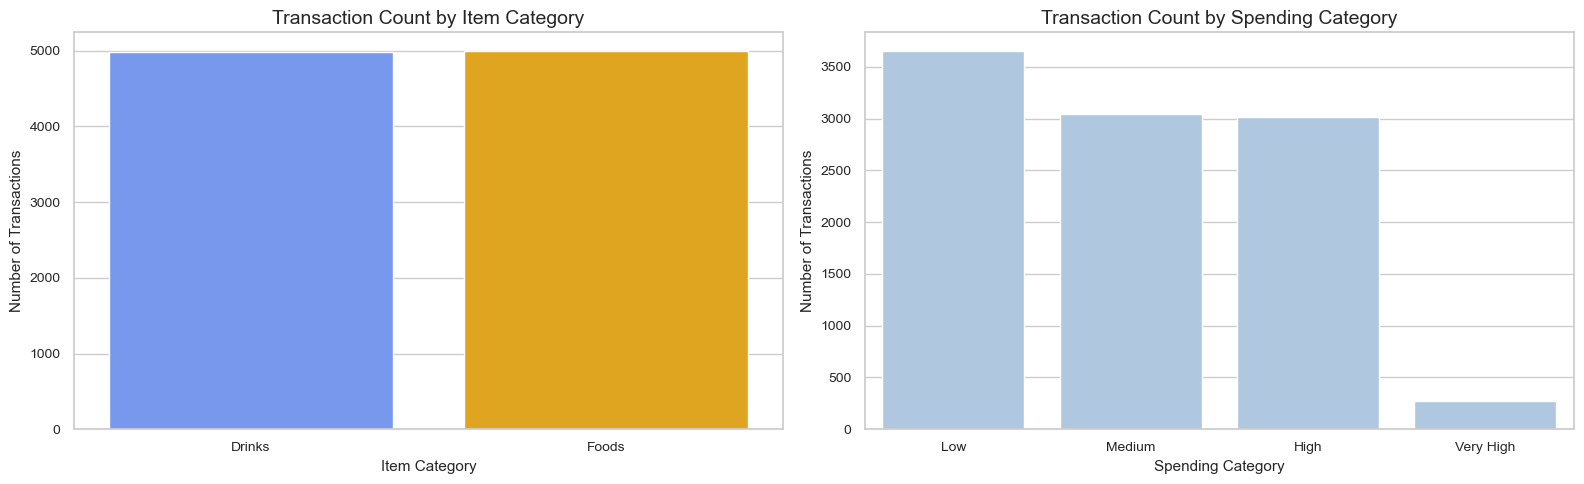

In [89]:
# Univariate Analysis: Distribusi Item Category dan Spending Category

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(
    data=df_viz,
    x='Item Category',
    hue='Item Category',
    palette=category_palette,
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Transaction Count by Item Category')
axes[0].set_xlabel('Item Category')
axes[0].set_ylabel('Number of Transactions')

spending_order = ['Low', 'Medium', 'High', 'Very High']

sns.countplot(
    data=df_viz,
    x='Spending Category',
    order=spending_order,
    color='#A7C7E7',
    ax=axes[1]
)

axes[1].set_title('Transaction Count by Spending Category')
axes[1].set_xlabel('Spending Category')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

Analisis univariate menunjukkan distribusi transaksi berdasarkan kategori produk dan kategori spending. Bagian ini membantu mengetahui kelompok transaksi mana yang paling banyak muncul dalam dataset.

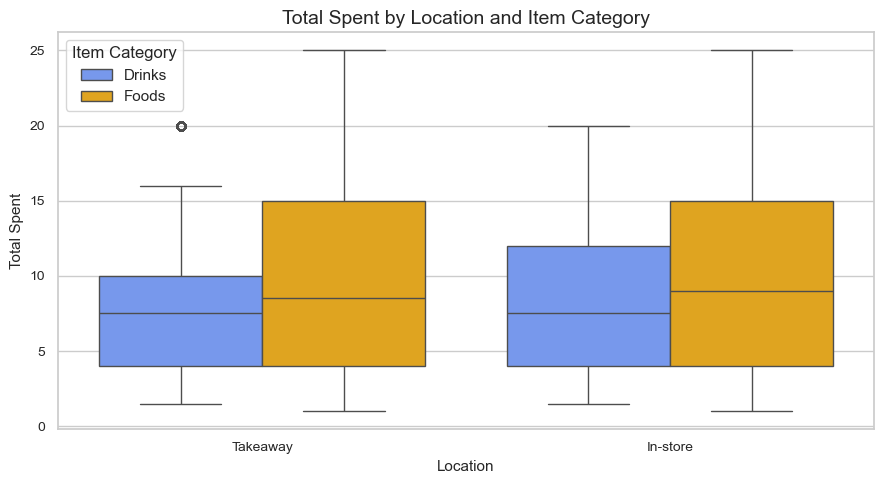

In [90]:
# Bivariate Analysis: Total Spent by Item Category and Location

plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=df_viz,
    x='Location',
    y='Total Spent',
    hue='Item Category',
    palette=category_palette
)

ax.set_title('Total Spent by Location and Item Category')
ax.set_xlabel('Location')
ax.set_ylabel('Total Spent')
ax.legend(title='Item Category')

plt.tight_layout()
plt.show()

Analisis bivariate ini membandingkan nilai transaksi berdasarkan lokasi dan kategori produk. Dengan grafik ini, dapat dilihat apakah transaksi Foods atau Drinks memiliki distribusi nilai yang berbeda pada lokasi In-store dan Takeaway.

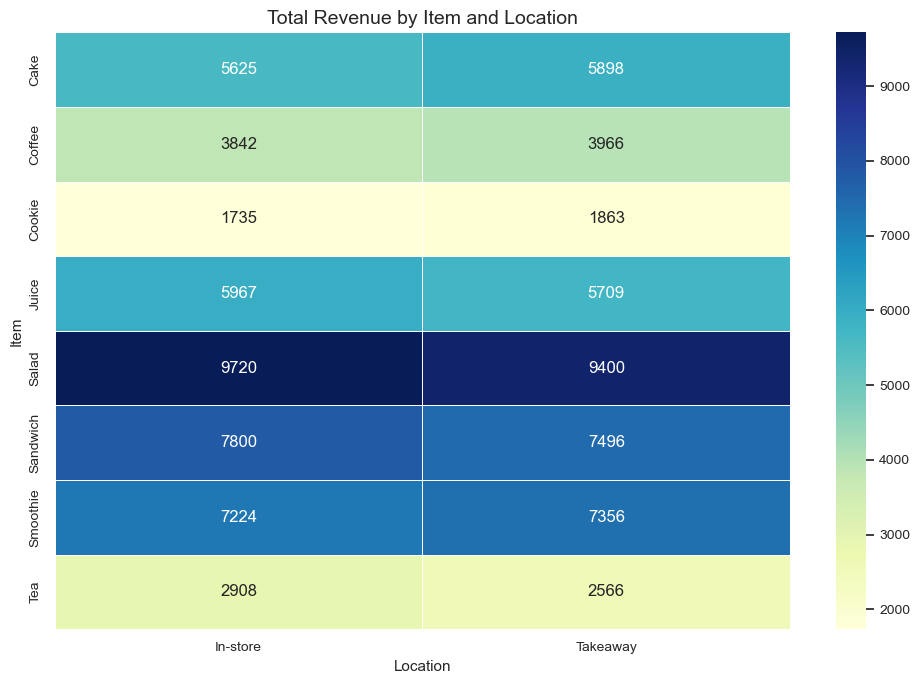

In [91]:
# Multivariate Analysis: Revenue by Item, Location, and Category

pivot_item_location = df_viz.pivot_table(
    values='Total Spent',
    index='Item',
    columns='Location',
    aggfunc='sum'
)

plt.figure(figsize=(10, 7))
ax = sns.heatmap(
    pivot_item_location,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5
)

ax.set_title('Total Revenue by Item and Location')
ax.set_xlabel('Location')
ax.set_ylabel('Item')

plt.tight_layout()
plt.show()

Analisis multivariate menunjukkan hubungan antara Item, Location, dan Total Spent. Heatmap ini membantu melihat produk mana yang menghasilkan revenue terbesar pada masing-masing lokasi transaksi.

## 5. Advanced EDA Techniques

In [92]:
# Cross Tabulation: Item Category vs Payment Method

category_payment_crosstab = pd.crosstab(
    df_viz['Item Category'],
    df_viz['Payment Method'],
    normalize='index'
) * 100

category_payment_crosstab

Payment Method,Cash,Credit Card,Digital Wallet
Item Category,,,
Drinks,32.731286,32.711218,34.557495
Foods,33.426798,33.907470,32.665732


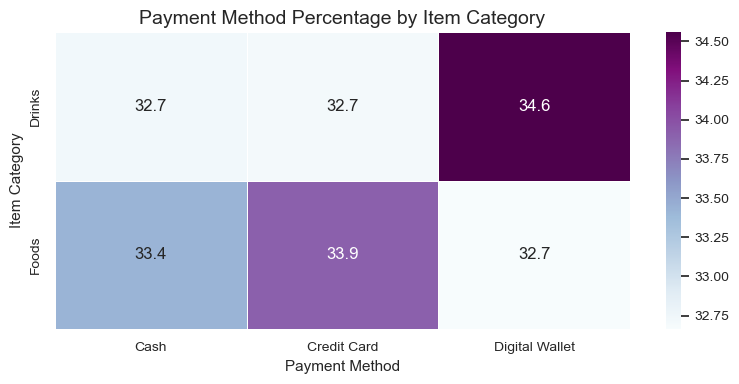

In [93]:
# Visualisasi Cross Tabulation dalam bentuk heatmap persentase

plt.figure(figsize=(8, 4))
ax = sns.heatmap(
    category_payment_crosstab,
    annot=True,
    fmt='.1f',
    cmap='BuPu',
    linewidths=0.5
)

ax.set_title('Payment Method Percentage by Item Category')
ax.set_xlabel('Payment Method')
ax.set_ylabel('Item Category')

plt.tight_layout()
plt.show()

Cross tabulation menunjukkan proporsi metode pembayaran pada setiap kategori produk. Karena ditampilkan dalam persentase, grafik ini lebih mudah digunakan untuk membandingkan pola pembayaran antara Foods dan Drinks.

In [94]:
# Grouping: Revenue Summary by Item Category, Item, and Payment Method

advanced_grouping = df_viz.groupby(
    ['Item Category', 'Item', 'Payment Method']
).agg(
    Total_Revenue=('Total Spent', 'sum'),
    Total_Transaction=('Transaction ID', 'count'),
    Average_Spending=('Total Spent', 'mean')
).sort_values(by='Total_Revenue', ascending=False)

advanced_grouping.head(10)

Total_Revenue  Total_Transaction  \
Item Category Item     Payment Method                                     
Foods         Salad    Cash                   6700.0                443   
                       Credit Card            6515.0                440   
                       Digital Wallet         5905.0                388   
              Sandwich Credit Card            5368.0                438   
                       Digital Wallet         5120.0                417   
Drinks        Smoothie Digital Wallet         4988.0                412   
                       Cash                   4928.0                401   
Foods         Sandwich Cash                   4808.0                393   
Drinks        Smoothie Credit Card            4664.0                387   
              Juice    Digital Wallet         4038.0                445   

                                       Average_Spending  
Item Category Item     Payment Method                    
Foods         Salad    Cash                   15.124153  
                       Credit Card            14.806818  
                       Digital Wallet         15.219072  
              Sandwich Credit Card            12.255708  
                       Digital Wallet         12.278177  
Drinks        Smoothie Digital Wallet         12.106796  
                       Cash                   12.289277  
Foods         Sandwich Cash                   12.234097  
Drinks        Smoothie Credit Card            12.051680  
              Juice    Digital Wallet          9.074157

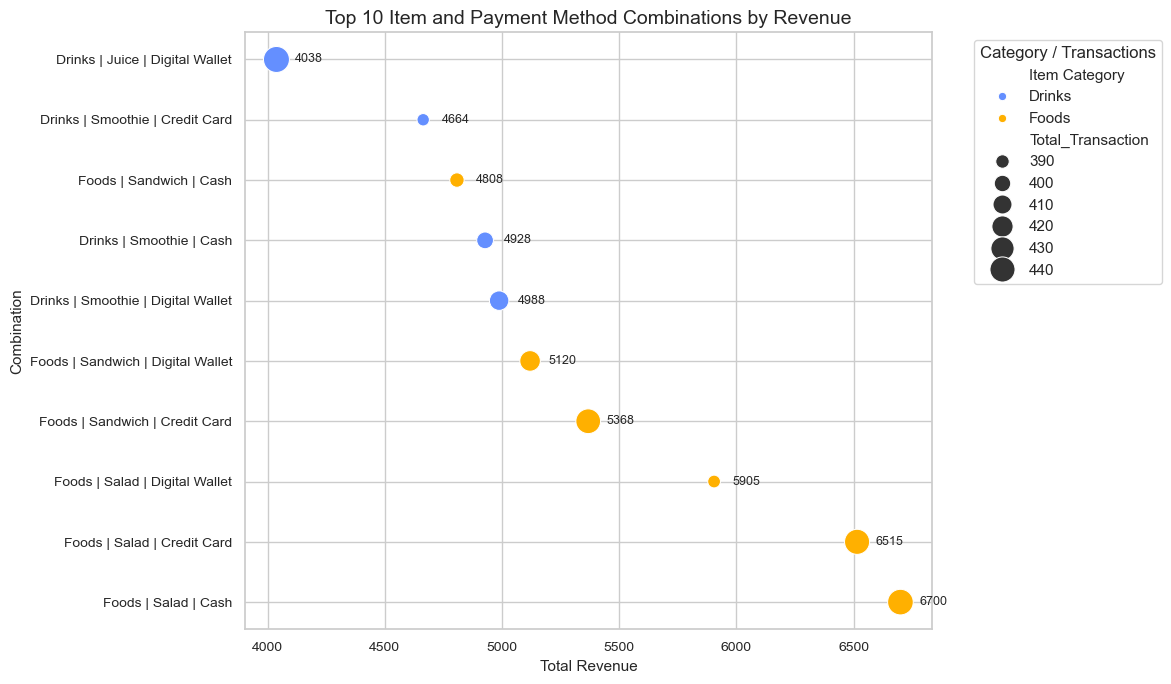

In [95]:
# Visualisasi Top 10 kombinasi Item dan Payment Method menggunakan dot plot

top_grouping = advanced_grouping.head(10).reset_index()
top_grouping['Combination'] = (
    top_grouping['Item Category'] + ' | ' +
    top_grouping['Item'] + ' | ' +
    top_grouping['Payment Method']
)

top_grouping = top_grouping.sort_values('Total_Revenue', ascending=True)

plt.figure(figsize=(12, 7))
ax = sns.scatterplot(
    data=top_grouping,
    x='Total_Revenue',
    y='Combination',
    hue='Item Category',
    size='Total_Transaction',
    sizes=(80, 350),
    palette=category_palette
)

ax.set_title('Top 10 Item and Payment Method Combinations by Revenue')
ax.set_xlabel('Total Revenue')
ax.set_ylabel('Combination')
ax.legend(title='Category / Transactions', bbox_to_anchor=(1.05, 1), loc='upper left')

for _, row in top_grouping.iterrows():
    ax.text(
        row['Total_Revenue'] + 80,
        row['Combination'],
        f"{row['Total_Revenue']:.0f}",
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

Grouping digunakan untuk mengetahui kombinasi kategori produk, item, dan metode pembayaran yang memberikan revenue terbesar. Dot plot dipilih agar visualisasi tidak terus-menerus menggunakan bar chart.

In [96]:
# Random Sampling
# Mengambil sampel acak sebanyak 10 data

sample_data = df_viz.sample(n=10, random_state=42)
sample_data

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Date Status,Year,Month,Month Name,Day Name,Item Category,Spending Category
5837,TXN_5318263,Smoothie,1,4.0,4.0,Credit Card,Takeaway,2023-06-12,Date Available,2023,6,June,Monday,Drinks,Low
5183,TXN_3075169,Sandwich,2,4.0,8.0,Credit Card,In-store,2023-06-25,Date Available,2023,6,June,Sunday,Foods,Medium
6054,TXN_6857799,Cookie,4,1.0,4.0,Cash,Takeaway,2023-01-08,Date Available,2023,1,January,Sunday,Foods,Low
107,TXN_9547091,Cookie,3,1.0,3.0,Credit Card,Takeaway,2023-10-08,Date Available,2023,10,October,Sunday,Foods,Low
3432,TXN_4156369,Cake,5,3.0,15.0,Credit Card,In-store,2023-08-07,Date Available,2023,8,August,Monday,Foods,High
39,TXN_6688524,Coffee,4,2.0,8.0,Cash,In-store,2023-06-29,Date Available,2023,6,June,Thursday,Drinks,Medium
6413,TXN_9067597,Salad,4,5.0,20.0,Cash,Takeaway,2023-11-02,Date Available,2023,11,November,Thursday,Foods,High
4547,TXN_5926836,Cake,5,3.0,15.0,Credit Card,In-store,2023-08-07,Date Available,2023,8,August,Monday,Foods,High
6058,TXN_1959082,Juice,5,3.0,15.0,Credit Card,In-store,2023-06-08,Date Available,2023,6,June,Thursday,Drinks,High
2560,TXN_4435352,Salad,2,5.0,10.0,Credit Card,In-store,2023-05-03,Date Available,2023,5,May,Wednesday,Foods,Medium


Random sampling digunakan untuk melihat contoh data transaksi secara acak tanpa harus menampilkan seluruh dataset.

In [97]:
# Filtering High Value Transaction

high_value_transaction = df_viz[df_viz['Total Spent'] >= 20].copy()

high_value_summary = high_value_transaction.groupby('Item Category').agg(
    Total_Revenue=('Total Spent', 'sum'),
    Total_Transaction=('Transaction ID', 'count'),
    Average_Spending=('Total Spent', 'mean')
).sort_values(by='Total_Revenue', ascending=False)

high_value_summary

,Total_Revenue,Total_Transaction,Average_Spending
Item Category,,,
Foods,17405.0,803,21.674969
Drinks,5080.0,254,20.000000


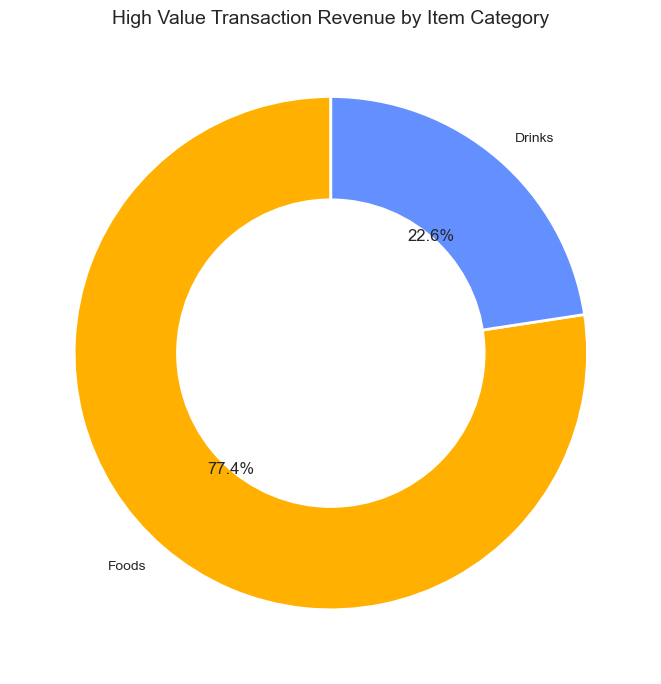

In [98]:
# Visualisasi High Value Transaction menggunakan donut chart

fig, ax = plt.subplots(figsize=(7, 7))

high_value_revenue = high_value_summary['Total_Revenue']
colors = [category_palette.get(label, '#BBBBBB') for label in high_value_revenue.index]

ax.pie(
    high_value_revenue.values,
    labels=high_value_revenue.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

centre_circle = plt.Circle((0, 0), 0.60, fc='white')
ax.add_artist(centre_circle)

ax.set_title('High Value Transaction Revenue by Item Category')

plt.tight_layout()
plt.show()

Filtering high value transaction digunakan untuk menganalisis transaksi dengan nilai tinggi. Dengan kategori Foods dan Drinks, dapat dilihat kelompok produk mana yang lebih dominan dalam transaksi bernilai besar.

## 6. Insight & Kesimpulan

Berdasarkan hasil Exploratory Data Analysis, beberapa insight utama yang diperoleh adalah:

1. Produk berhasil dikelompokkan menjadi dua kategori utama, yaitu **Foods** dan **Drinks**, sehingga analisis revenue dapat dilihat tidak hanya per item tetapi juga per kelompok produk.
2. Revenue cafe dipengaruhi oleh kombinasi antara jenis item, quantity, dan price per unit.
3. Analisis kategori membantu melihat apakah makanan atau minuman lebih dominan terhadap revenue dan transaksi bernilai tinggi.
4. Analisis Payment Method dan Location menunjukkan pola transaksi pelanggan dari sisi metode pembayaran dan lokasi pembelian.
5. Data **Transaction Date** yang kosong tidak dihapus, sehingga tetap dapat digunakan untuk analisis non-waktu. Namun, data tersebut tidak dapat digunakan untuk mengetahui bulan transaksi secara langsung karena informasi bulan berasal dari tanggal itu sendiri.
6. Missing Transaction Date dianalisis sebagai bagian dari **data quality analysis** melalui Date Status, kategori Unknown pada Month Name dan Day Name, serta missing rate berdasarkan Item Category, Item, Payment Method, dan Location.
7. High value transaction dapat menjadi fokus strategi bisnis karena kelompok transaksi ini memberikan kontribusi besar terhadap pendapatan.

Secara keseluruhan, dataset ini dapat digunakan untuk memahami pola transaksi cafe, mengidentifikasi kategori produk yang paling berkontribusi terhadap revenue, serta mengevaluasi kualitas data terutama pada kolom Transaction Date. Dari perspektif bisnis, hasil analisis dapat membantu menentukan strategi promosi produk, evaluasi metode pembayaran, serta meningkatkan kualitas pencatatan data transaksi agar analisis tren waktu menjadi lebih akurat.
